# **TAHAP 1 — Persiapan Lingkungan**

In [1]:
!pip install transformers sentence-transformers umap-learn hdbscan pandas numpy matplotlib seaborn

# **TAHAP 2 — Load Dataset dari Apify**

In [18]:
import pandas as pd

df = pd.read_excel("youtube_comments.xlsx")

df.head()


,author,comment,commentsCount,pageUrl,replyCount,title,type,videoID,voteCount
0,@Bennix,SEGERA isi Petisi Mendukung purbaya REDENOMINA...,6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,339,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,1000
1,@SamsFirdaus-lz3it,Kasian duit2 para koruptor nggak akan berlaku ...,6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,0,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,0
2,@Arew-hv1nk,gaskeuunnn..pa purbaya,6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,0,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,0
3,@BaritoputerariauGreatsupporter,"2 RUPIAH setara Rp.2.000,- 5 RUPIAH setara Rp....",6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,0,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,1
4,@sicimolgemol,Jangan lupa kasih tau sanak saudara teman atau...,6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,0,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,0


In [23]:
df = df.dropna(subset=["author"])

In [22]:
df.head()

,author,comment,commentsCount,pageUrl,replyCount,title,type,videoID,voteCount
0,@Bennix,SEGERA isi Petisi Mendukung purbaya REDENOMINA...,6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,339,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,1000
1,@SamsFirdaus-lz3it,Kasian duit2 para koruptor nggak akan berlaku ...,6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,0,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,0
2,@Arew-hv1nk,gaskeuunnn..pa purbaya,6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,0,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,0
3,@BaritoputerariauGreatsupporter,"2 RUPIAH setara Rp.2.000,- 5 RUPIAH setara Rp....",6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,0,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,1
4,@sicimolgemol,Jangan lupa kasih tau sanak saudara teman atau...,6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,0,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,0


In [26]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s.,!?]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


df["comment"] = df["comment"].astype(str)

df["clean_text"] = df["comment"].apply(clean_text)
df.head()

,author,comment,commentsCount,pageUrl,replyCount,title,type,videoID,voteCount,clean_text
0,@Bennix,SEGERA isi Petisi Mendukung purbaya REDENOMINA...,6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,339,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,1000,segera isi petisi mendukung purbaya redenomina...
1,@SamsFirdaus-lz3it,Kasian duit2 para koruptor nggak akan berlaku ...,6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,0,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,0,kasian duit2 para koruptor nggak akan berlaku ...
2,@Arew-hv1nk,gaskeuunnn..pa purbaya,6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,0,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,0,gaskeuunnn..pa purbaya
3,@BaritoputerariauGreatsupporter,"2 RUPIAH setara Rp.2.000,- 5 RUPIAH setara Rp....",6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,0,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,1,"2 rupiah setara rp.2.000, 5 rupiah setara rp.5..."
4,@sicimolgemol,Jangan lupa kasih tau sanak saudara teman atau...,6358,https://youtu.be/GRA-0D9PojY?si=RNrPNibbLbVH9BRT,0,"REDENOMINASI PURBAYA! Uang Rp1000 Jadi Rp1, Ri...",comment,NaN,0,jangan lupa kasih tau sanak saudara teman atau...


# **TAHAP 4 — Generate Embedding dengan IndoBERT / Sentence-BERT**

* Sentence-BERT multilingual

In [27]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

embeddings = model.encode(df["clean_text"].tolist(), show_progress_bar=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/37 [00:00<?, ?it/s]

# **TAHAP 5 — Dimensionality Reduction dengan UMAP**

UMAP sangat cocok untuk:

* text embedding

* clustering + visualisasi

In [28]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

umap_embeddings = umap_model.fit_transform(embeddings)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# **TAHAP 6 — Clustering dengan HDBSCAN**

* Tidak perlu menentukan jumlah cluster

* Bisa menangani data noisy

* Bisa menghasilkan cluster "besar" dan "kecil"

In [29]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric='euclidean',
    cluster_selection_method='eom'
)

df["cluster"] = clusterer.fit_predict(umap_embeddings)


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


# **TAHAP 7 — Menampilkan Jumlah Cluster**

In [31]:
df["cluster"].value_counts()

,count
cluster,
0,612
2,342
-1,76
5,68
4,34
1,24
3,18


# **TAHAP 8 — Interpretasi Setiap Cluster**
* lihat isi komentar di tiap cluster

In [43]:
def show_cluster(n, sample=100):
    print(f"--- Cluster {n}  ---")
    display(df[df["cluster"] == n]["clean_text"].head(sample))

show_cluster(0)
show_cluster(1)
show_cluster(2)
show_cluster(-1)

--- Cluster 0  ---


,clean_text
55,setuju
56,setuju
91,setuju pol
139,setuju
161,setuju
168,setuju
180,setuju
190,sy setuju
228,setuju
255,setuju


--- Cluster 1  ---


,clean_text
2,gaskeuunnn..pa purbaya
4,jangan lupa kasih tau sanak saudara teman atau...
5,bantu share aja bang. biar masyarakat pada pinter
11,bismilah saya sekeluarga ikhlas pak purbaya
13,si abang kepinteran banyak sekali kata2 bodok ...
...,...
356,makasih pencerahannya bro bennix
360,setuju banget karena saya sudah pernah mengala...
361,mantap mampus kruptor
370,"ternyata emang se impactfull itu ternyata, gw ..."


--- Cluster 2  ---


,clean_text
19,berarti bank indonesia harus mencetak uang bar...
32,ini lah sa at indonesia tidak bisa dipandang r...
189,jgan jauh jauh bang malaysia 50 ringgit tukar ...
199,"makin enak dan simpel, itu yang aku rasakan di..."
238,-sv9qo ringgit tinggi tapi negara digadai ke u...
254,info perhari ini ringgit malaysia menguat di 4...
284,saya pernah ngawal atasan nukar rupiah ke us d...
318,"-sv9qo kenapa juga harus nyebut malaydesh, neg..."
430,mata uang rupiah ga kecil soalnya indonesia ga...
483,bagaimana kemudian sekirarnya uang hasil korup...


--- Cluster -1  ---


,clean_text
0,segera isi petisi mendukung purbaya redenomina...
10,setuju banget...redominasi solusi yg sdh lama ...
18,dan satu lagi saran bang nilainya. dari cent 1...
36,ga perlu petisi
61,aq sevagai pekerja luar negri sangat mendukung...
...,...
794,om bennix bahas bensin baru karya anak bangsa ...
801,setuju redenominasi om bennix. duit duit di da...
802,gasss
807,"kalau ada orang yang menolak redenominasi, sep..."


# **TAHAP 9 — Visualisasi Clustering (Grafik 2D)**

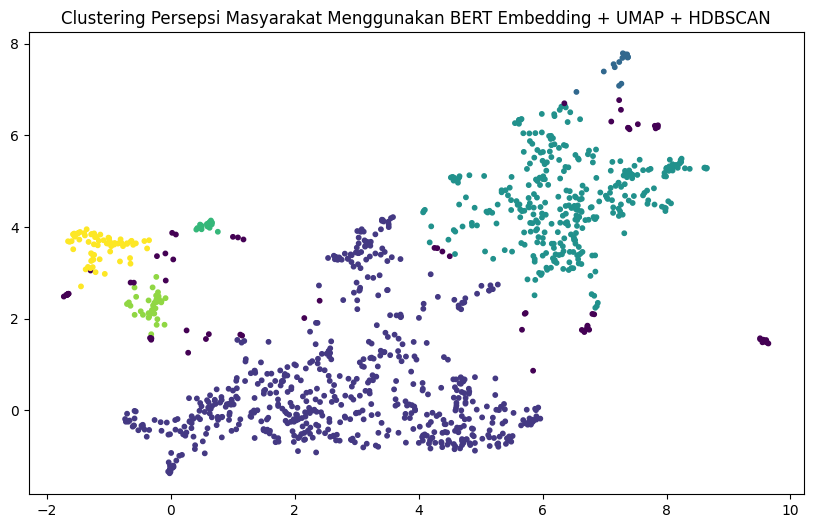

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(umap_embeddings[:,0], umap_embeddings[:,1],
            c=df["cluster"], s=10)
plt.title("Clustering Persepsi Masyarakat Menggunakan BERT Embedding + UMAP + HDBSCAN")
plt.show()


In [44]:
df.to_csv("clustered_comments.csv", index=False)

**TAHAP 10 — Ekstraksi Kata Dominan per Cluster**

* TF-IDF untuk mengekstrak keyword per cluster.

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def get_top_keywords(cluster_id, n_keywords=10):
    texts = df[df["cluster"] == cluster_id]["clean_text"].tolist()

    vectorizer = TfidfVectorizer(stop_words='indonesian', max_features=3000)
    tfidf = vectorizer.fit_transform(texts)

    scores = np.asarray(tfidf.sum(axis=0)).ravel().tolist()
    vocab = vectorizer.get_feature_names_out()

    top_idx = np.argsort(scores)[::-1][:n_keywords]
    top_keywords = [vocab[i] for i in top_idx]

    return top_keywords


clusters = sorted(df["cluster"].unique())

for c in clusters:
    if c != -1:
        print(f"\n=== Cluster {c} ===")
        print(get_top_keywords(c))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning:

Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.




=== Cluster 0 ===
['setuju', 'setujuu', 'nice', 'sy', 'pol', 'n1i']

=== Cluster 1 ===
['setuju', 'purbaya', 'dukung', 'bang', 'mantap', 'banget', 'mendukung', 'yg', 'nya', 'ya']

=== Cluster 2 ===
['indonesia', 'uang', 'malaysia', 'rupiah', 'ringgit', 'aja', 'setuju', 'juta', '000', 'yg']

=== Cluster 3 ===
['indonesia', 'redenominasi', 'setuju', 'purbaya', 'maju', 'ekonomi', 'mendukung', 'rakyat', 'yg', 'semoga']

=== Cluster 4 ===
['setuju', 'redenominasi', 'dukung', 'mendukung', 'purbaya', 'bagus', 'banget', 'yg', 'lanjutkan', 'gak']

=== Cluster 5 ===
['uang', 'koruptor', 'redenominasi', 'rupiah', 'yg', 'setuju', 'rp', 'nya', '100', 'sen']


**TAHAP 11 — Menampilkan Komentar Paling Representatif (Centroid Nearest Comments)**

* Komentar paling representatif = komentar paling dekat dengan pusat cluster.

In [48]:
import numpy as np

def get_representative_comments(cluster_id, top_n=5):
    idxs = df[df["cluster"] == cluster_id].index.tolist()
    cluster_embeds = embeddings[idxs]

    centroid = cluster_embeds.mean(axis=0)

    distances = np.linalg.norm(cluster_embeds - centroid, axis=1)
    top_idxs = distances.argsort()[:top_n]

    representative = df.iloc[[idxs[i] for i in top_idxs]]["clean_text"].tolist()
    return representative


get_representative_comments(cluster_id=0, top_n=5)


['setuju', 'setuju', 'setuju', 'setuju', 'setuju']

**TAHAP 12 — Menyimpulkan TOPIK PERSEPSI OTOMATIS (Heuristic Labeling)**

In [49]:
def label_topic(keywords):
    kw = " ".join(keywords)

    if any(k in kw for k in ["bingung", "gimana", "ribet", "pusing"]):
        return "Kebingungan Masyarakat"
    if any(k in kw for k in ["setuju", "baik", "mendukung", "bagus"]):
        return "Dukungan Terhadap Kebijakan"
    if any(k in kw for k in ["mahal", "inflasi", "harga", "naik"]):
        return "Kekhawatiran Inflasi / Harga"
    if any(k in kw for k in ["pemerintah", "kebijakan", "aturan"]):
        return "Pandangan Terhadap Pemerintah"
    if any(k in kw for k in ["bohong", "tipu", "jahat"]):
        return "Ketidakpercayaan / Sikap Skeptis"
    if any(k in kw for k in ["lucu", "sarkas", "komedi"]):
        return "Humor / Sarkasme"

    return "Persepsi Umum / Tidak Terdefinisi"


**TAHAP 13 — Menggabungkan Semuanya → Interpretasi Lengkap Setiap Cluster**

In [52]:
def interpret_cluster(cluster_id):
    print("="*50)
    print(f" CLUSTER {cluster_id}")
    print("="*50)

    # 1. Kata kunci
    keywords = get_top_keywords(cluster_id)
    print("\n🔹 Kata Kunci Dominan:")
    print(keywords)

    # 2. Topik persepsi
    topic = label_topic(keywords)
    print("\n🔹 Topik Persepsi Utama:")
    print(topic)

    # 3. Komentar representatif
    reps = get_representative_comments(cluster_id)
    print("\n🔹 Contoh Komentar Representatif:")
    for r in reps:
        print("-", r)


for c in clusters:
    if c != -1:
        interpret_cluster(c)


 CLUSTER 0

🔹 Kata Kunci Dominan:
['setuju', 'setujuu', 'nice', 'sy', 'pol', 'n1i']

🔹 Topik Persepsi Utama:
Dukungan Terhadap Kebijakan

🔹 Contoh Komentar Representatif:
- setuju
- setuju
- setuju
- setuju
- setuju
 CLUSTER 1

🔹 Kata Kunci Dominan:
['setuju', 'purbaya', 'dukung', 'bang', 'mantap', 'banget', 'mendukung', 'yg', 'nya', 'ya']

🔹 Topik Persepsi Utama:
Dukungan Terhadap Kebijakan

🔹 Contoh Komentar Representatif:
- aq setuju banget sama pak purbaya
- bantu share aja bang. biar masyarakat pada pinter
- setuju jossss pak purbaya
- setuju redomenasi pak
- aku dukung purbaya
 CLUSTER 2

🔹 Kata Kunci Dominan:
['indonesia', 'uang', 'malaysia', 'rupiah', 'ringgit', 'aja', 'setuju', 'juta', '000', 'yg']

🔹 Topik Persepsi Utama:
Dukungan Terhadap Kebijakan

🔹 Contoh Komentar Representatif:
- ini lah sa at indonesia tidak bisa dipandang rendah lu jiran malaydesh buke mate besau besau kalau lihat uang rupiah indonesia indonesia
- sangat mendukung banget. alasan nya simpel sihh malu sa

## VISUALISASI TOPIK PER CLUSTER

In [53]:
import numpy as np

cluster_centroids = {}

for cluster_id in df["cluster"].unique():
    if cluster_id == -1:  # skip noise
        continue
    idx = df[df["cluster"] == cluster_id].index.tolist()
    cluster_centroids[cluster_id] = umap_embeddings[idx].mean(axis=0)


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning:

Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.



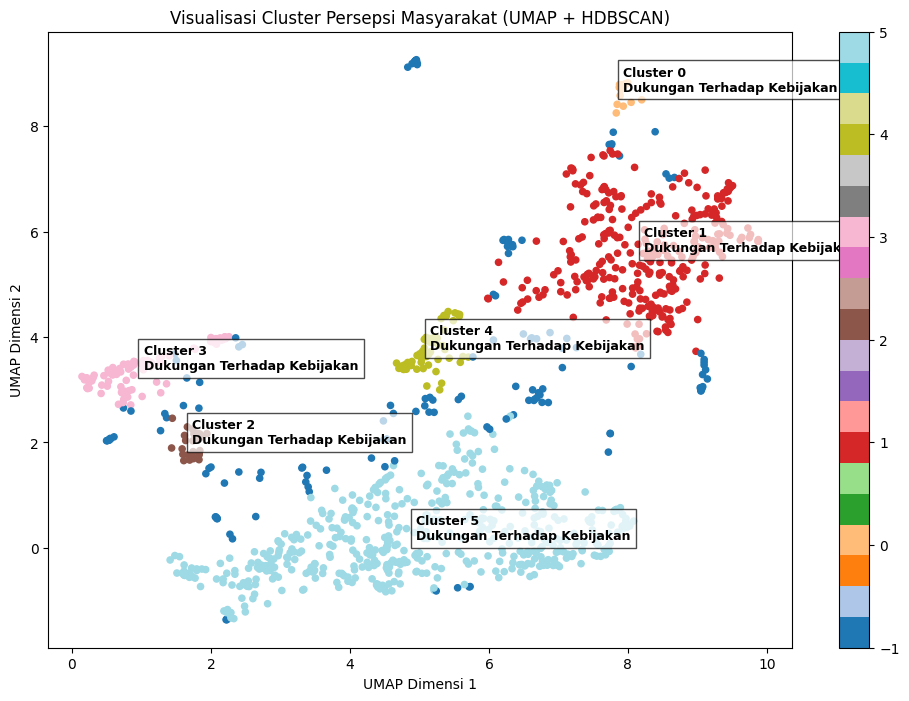

In [55]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))


scatter = plt.scatter(
    df[UMAP_2D_COLS[0]],
    df[UMAP_2D_COLS[1]],
    c=df["cluster"],
    cmap="tab20",
    s=20
)

plt.title("Visualisasi Cluster Persepsi Masyarakat (UMAP + HDBSCAN)")
plt.xlabel("UMAP Dimensi 1")
plt.ylabel("UMAP Dimensi 2")


cluster_centroids = {}
for cluster_id in sorted(df["cluster"].unique()):
    if cluster_id == -1:
        continue

    cluster_umap_coords = df[df["cluster"] == cluster_id][list(UMAP_2D_COLS)].values
    if len(cluster_umap_coords) > 0:
        cluster_centroids[cluster_id] = cluster_umap_coords.mean(axis=0)

# Tambah label topik
for cluster_id, centroid in cluster_centroids.items():
    keywords = get_top_keywords(cluster_id)
    topic_label = label_topic(keywords)

    plt.text(
        centroid[0],
        centroid[1],
        f"Cluster {cluster_id}\n{topic_label}",
        fontsize=9,
        weight="bold",
        bbox=dict(facecolor='white', alpha=0.7, edgecolor="black")
    )

plt.colorbar(scatter)
plt.show()

## **WORDCLOUD PER CLUSTER**

In [60]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [61]:
def generate_wordcloud(cluster_id):
    text = " ".join(df[df["cluster"] == cluster_id]["clean_text"].tolist())

    wc = WordCloud(
        width=1200,
        height=800,
        background_color="white",
        collocations=False
    ).generate(text)

    plt.figure(figsize=(10, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")

    keywords = get_top_keywords(cluster_id)
    topic_label = label_topic(keywords)

    plt.title(f"Wordcloud Cluster {cluster_id} — {topic_label}", fontsize=14)
    plt.show()


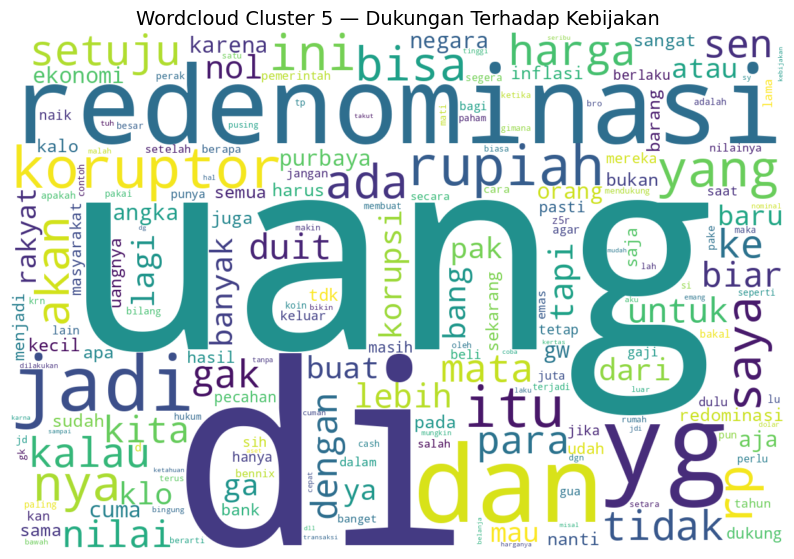

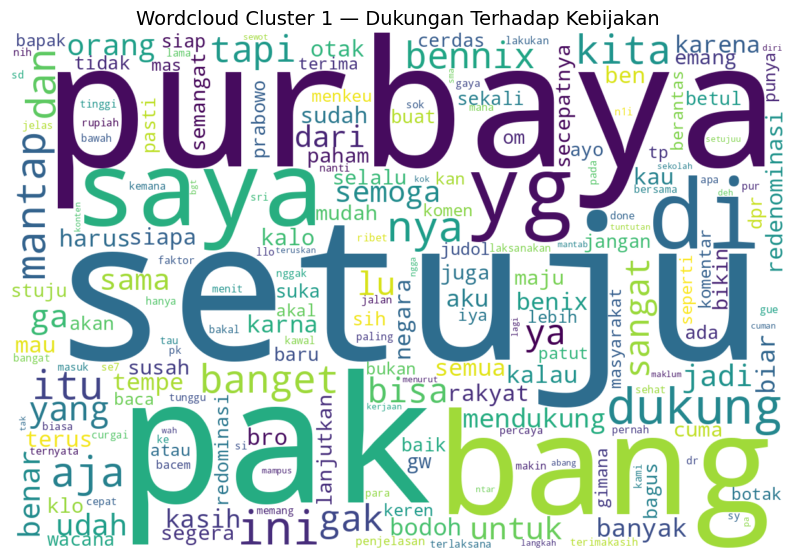

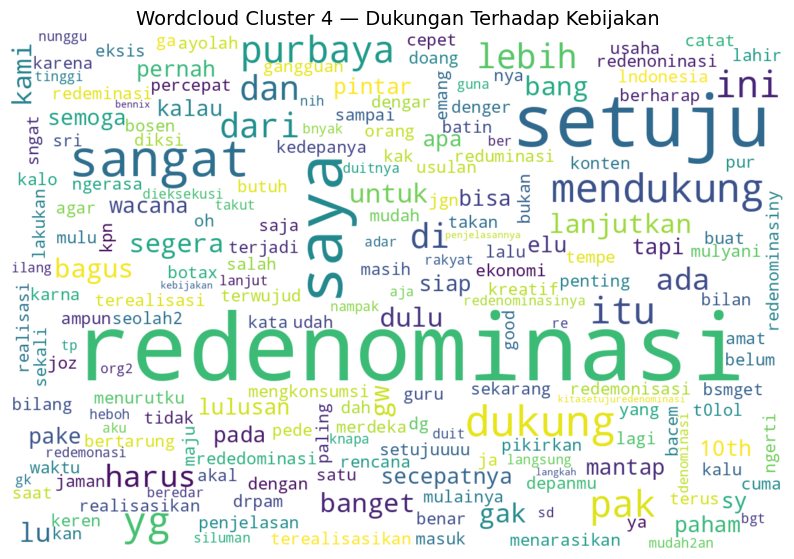

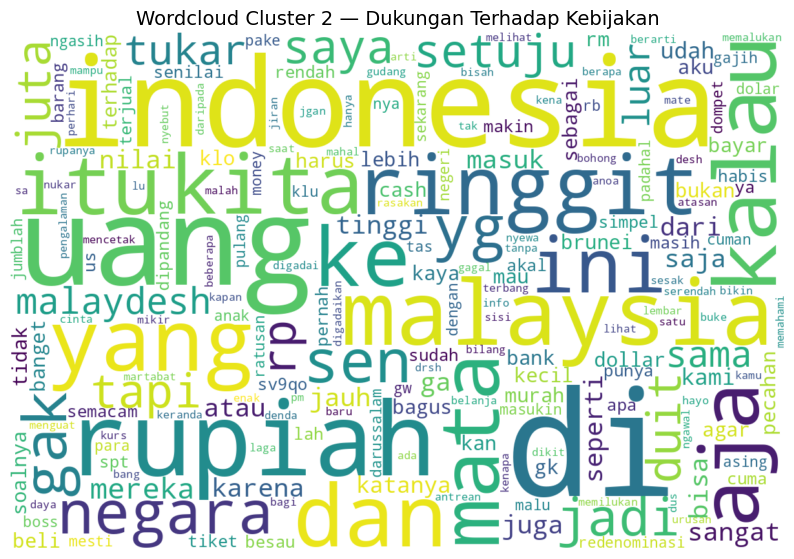

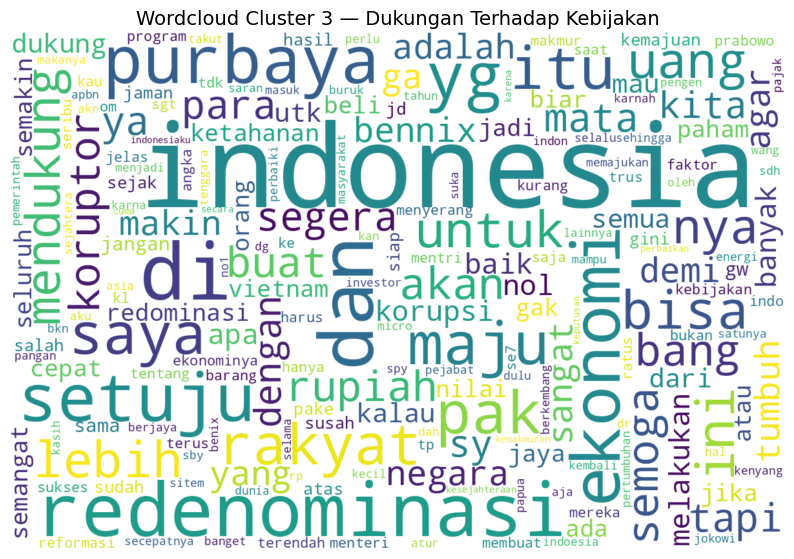

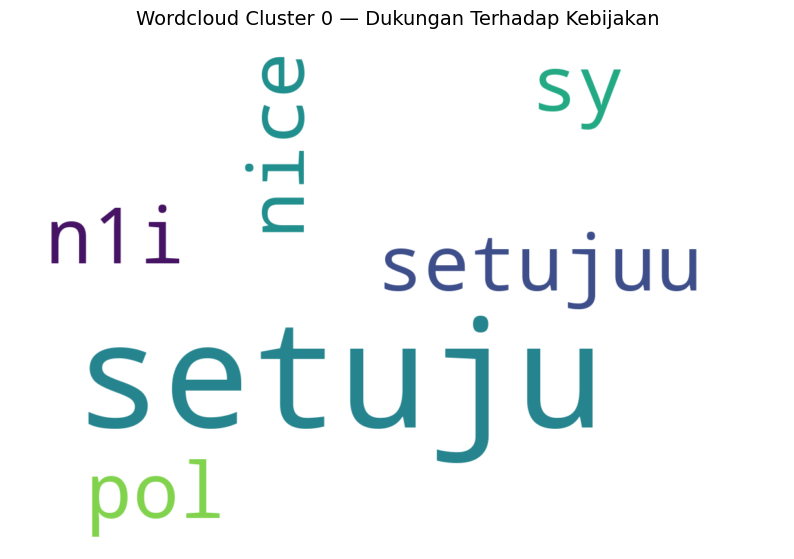

In [62]:
for c in df["cluster"].unique():
    if c != -1:
        generate_wordcloud(c)
